# SS_02 - Segmentacion Tumoral (SegResNet BraTS23)

**Pipeline SS (Skull Stripping)** - Notebook 2 de 6

Este notebook aplica segmentacion tumoral con SegResNet BraTS23 sobre las
imagenes skull-stripped generadas por SS_01.

**Optimizacion**: Los datos se copian a memoria local de Colab antes de
procesar para eliminar latencia de Drive.

**Entrada**: `SS_PIPELINE/stripped_images/` (722 casos)
**Salida**: `SS_PIPELINE/predictions/` (mascaras binarias whole tumor)

**Prerequisito**: Haber completado SS_01_skull_stripping.ipynb
**Prerequisito**: GPU A100 activa (Entorno de ejecucion -> Cambiar tipo -> A100)

In [ ]:
# CELDA 1 - Instalacion de dependencias
!pip install monai[all] nibabel numpy pandas tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10

In [ ]:
# CELDA 2 - Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELDA 3 - Imports y configuracion global
import os
import warnings
import traceback
import shutil
from pathlib import Path
from typing import Dict, List

import numpy as np
import nibabel as nib
import nibabel.orientations as nibo
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

import monai
from monai.bundle import load
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd,
)
from monai.inferers import sliding_window_inference

warnings.filterwarnings('ignore')

BASE_DRIVE     = Path('/content/drive/MyDrive/GBM_TESIS')
SS_DIR         = BASE_DRIVE / 'SS_PIPELINE'
SS_STRIPPED    = SS_DIR / 'stripped_images'
SS_PRED        = SS_DIR / 'predictions'
SS_METRICS     = SS_DIR / 'metrics'
SS_FIGURES     = SS_DIR / 'figures'
BUNDLE_PATH    = BASE_DRIVE / 'MODELO PREENTRENADO/models/brats_mri_segmentation'
GT_DIR         = BASE_DRIVE / 'Dataset/images_segm_binary'

# Directorio local temporal
LOCAL_STRIPPED = Path('/content/stripped_images_local')

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROI_SIZE      = (128, 128, 128)
SW_BATCH_SIZE = 4
OVERLAP       = 0.5

for d in [SS_PRED, SS_METRICS, SS_FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Dispositivo : {DEVICE}')
print(f'GPU         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU"}')
print(f'MONAI       : {monai.__version__}')
print(f'\nVerificando rutas:')
print(f'  SS_STRIPPED : {"✅" if SS_STRIPPED.exists() else "❌"} ({len(list(SS_STRIPPED.iterdir()))} casos)' if SS_STRIPPED.exists() else f'  SS_STRIPPED : ❌')
print(f'  BUNDLE      : {"✅" if BUNDLE_PATH.exists() else "❌"} {BUNDLE_PATH}')
print(f'  GT_DIR      : {"✅" if GT_DIR.exists() else "❌"} {GT_DIR}')

drive_prefix = str(SS_STRIPPED)
local_prefix = str(LOCAL_STRIPPED)


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Dispositivo : cuda
GPU         : NVIDIA A100-SXM4-40GB
MONAI       : 1.5.2

Verificando rutas:
  SS_STRIPPED : ✅ (722 casos)
  BUNDLE      : ✅ /content/drive/MyDrive/GBM_TESIS/MODELO PREENTRENADO/models/brats_mri_segmentation
  GT_DIR      : ✅ /content/drive/MyDrive/GBM_TESIS/Dataset/images_segm_binary


In [ ]:
# CELDA 4 - Copiar datos a memoria local
# TIEMPO: ~10-15 minutos

if LOCAL_STRIPPED.exists():
    n_casos = len(list(LOCAL_STRIPPED.iterdir()))
    print(f'Directorio local ya existe con {n_casos} casos.')
else:
    print('Copiando stripped_images a memoria local...')
    print('Esto tarda ~10-15 minutos pero acelera el procesamiento 2-3x.')
    shutil.copytree(str(SS_STRIPPED), str(LOCAL_STRIPPED))
    n_casos = len(list(LOCAL_STRIPPED.iterdir()))
    print(f'Copia completada. Casos locales: {n_casos}')

statvfs = os.statvfs('/content')
free_gb = statvfs.f_frsize * statvfs.f_bavail / 1e9
print(f'Espacio libre en /content: {free_gb:.1f} GB')

Copiando stripped_images a memoria local...
Esto tarda ~10-15 minutos pero acelera el procesamiento 2-3x.
Copia completada. Casos locales: 722
Espacio libre en /content: 187.6 GB


In [ ]:
# CELDA 5 - Cargar modelo preentrenado SegResNet BraTS23

seg_model = load(name=str(BUNDLE_PATH), source='disk', net_override={})
seg_model.to(DEVICE)
seg_model.eval()
print(f'Modelo cargado en: {DEVICE}')
print(f'Parametros: {sum(p.numel() for p in seg_model.parameters()):,}')

2026-03-20 02:11:15,238 - INFO - Setting logging properties based on config: /content/drive/MyDrive/GBM_TESIS/MODELO PREENTRENADO/models/brats_mri_segmentation/configs/logging.conf.
2026-03-20 02:11:15,666 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-03-20 02:11:15,666 - INFO - > workflow_type: 'train'
2026-03-20 02:11:15,667 - INFO - ---


2026-03-20 02:11:15,758 - INFO - 'dst' model updated: 83 of 83 variables.
Modelo cargado en: cuda
Parametros: 4,702,227


In [ ]:
# CELDA 6 - Transforms de preprocesamiento
# Identico al notebook 01 original: NormalizeIntensityd de MONAI

preprocess = Compose([
    LoadImaged(keys=['t1', 't1ce', 't2', 'flair']),
    EnsureChannelFirstd(keys=['t1', 't1ce', 't2', 'flair']),
    Orientationd(keys=['t1', 't1ce', 't2', 'flair'], axcodes='RAS'),
    Spacingd(
        keys=['t1', 't1ce', 't2', 'flair'],
        pixdim=(1., 1., 1.),
        mode='bilinear',
    ),
    NormalizeIntensityd(
        keys=['t1', 't1ce', 't2', 'flair'],
        nonzero=True,
        channel_wise=True,
    ),
])

print('Transforms definidos.')

Transforms definidos.


In [ ]:
# CELDA 7 - Cargar indice de casos y actualizar rutas a local

index_path     = SS_DIR / 'ss_cases_index.csv'
df_cases       = pd.read_csv(str(index_path))
df_cases_drive = df_cases.copy()

# Actualizar rutas a local
for col in ['t1', 't1ce', 't2', 'flair']:
    df_cases[col] = df_cases[col].str.replace(drive_prefix, local_prefix, regex=False)

print(f'Casos disponibles     : {len(df_cases)}')
print(f'  UPENN unstripped    : {(df_cases["source"] == "UPENN_unstripped").sum()}')
print(f'  UPEN externos       : {(df_cases["source"] == "UPEN_stripped").sum()}')
print(f'\nEjemplo ruta local:')
print(f'  {df_cases["t1ce"].iloc[0]}')
print(f'\nEjemplo ruta Drive:')
print(f'  {df_cases_drive["t1ce"].iloc[0]}')


Casos disponibles     : 722
  UPENN unstripped    : 671
  UPEN externos       : 51

Ejemplo ruta local:
  /content/stripped_images_local/UPENN-GBM-00001_11/UPENN-GBM-00001_11_T1GD_stripped.nii.gz

Ejemplo ruta Drive:
  /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/stripped_images/UPENN-GBM-00001_11/UPENN-GBM-00001_11_T1GD_stripped.nii.gz


In [ ]:
# CELDA 8 - Funcion de segmentacion por caso

def run_segmentation_case(case: Dict, output_dir: Path) -> Dict:
    """
    Ejecuta inferencia de segmentacion con SegResNet BraTS23.
    Lee desde rutas locales, guarda mascara directamente en Drive.
    Reorienta la mascara al espacio original del T1ce.
    """
    sid     = case['sid']
    out_dir = output_dir / sid
    out_dir.mkdir(parents=True, exist_ok=True)

    data = preprocess({
        't1':    case['t1'],
        't1ce':  case['t1ce'],
        't2':    case['t2'],
        'flair': case['flair'],
    })

    image = torch.stack([
        data['t1'][0], data['t1ce'][0],
        data['t2'][0], data['flair'][0],
    ], dim=0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = sliding_window_inference(
            inputs=image,
            roi_size=ROI_SIZE,
            sw_batch_size=SW_BATCH_SIZE,
            predictor=seg_model,
            overlap=OVERLAP,
            mode='gaussian',
        )

    probs     = torch.sigmoid(logits)
    wt_binary = (probs[0, 1].cpu().numpy() > 0.5).astype(np.uint8)

    # Usar ruta Drive para affine de referencia
    ref_path  = case['t1ce'].replace(local_prefix, drive_prefix)
    ref_img   = nib.load(ref_path)
    orig_ornt = nibo.io_orientation(ref_img.affine)
    ras_ornt  = nibo.io_orientation(nib.as_closest_canonical(ref_img).affine)
    transform = nibo.ornt_transform(ras_ornt, orig_ornt)

    pred_nii        = nib.Nifti1Image(wt_binary, nib.as_closest_canonical(ref_img).affine)
    pred_reoriented = pred_nii.as_reoriented(transform)

    seg_path = out_dir / f'{sid}__seg.nii.gz'
    nib.save(pred_reoriented, str(seg_path))

    return {
        'sid':      sid,
        'seg_path': str(seg_path),
        'n_voxels': int(np.sum(wt_binary > 0)),
    }


print('Funcion run_segmentation_case definida.')

Funcion run_segmentation_case definida.


Casos con GT disponible para prueba: 10


Prueba segmentacion:  10%|█         | 1/10 [00:04<00:40,  4.48s/it]

  OK: UPENN-GBM-00002_11 | voxeles: 155,927 | Dice: 0.8242


Prueba segmentacion:  20%|██        | 2/10 [00:06<00:24,  3.12s/it]

  OK: UPENN-GBM-00006_11 | voxeles: 75,375 | Dice: 0.8698


...

  OK: UPENN-GBM-00016_11 | voxeles: 46,545 | Dice: 0.8848


Prueba segmentacion:  90%|█████████ | 9/10 [00:21<00:02,  2.19s/it]

  OK: UPENN-GBM-00017_11 | voxeles: 31,224 | Dice: 0.7655


Prueba segmentacion: 100%|██████████| 10/10 [00:23<00:00,  2.37s/it]

  OK: UPENN-GBM-00018_11 | voxeles: 118,435 | Dice: 0.7271

Dice medio  : 0.7996
Dice mediana: 0.8235
Dice min    : 0.6711
Dice max    : 0.8901


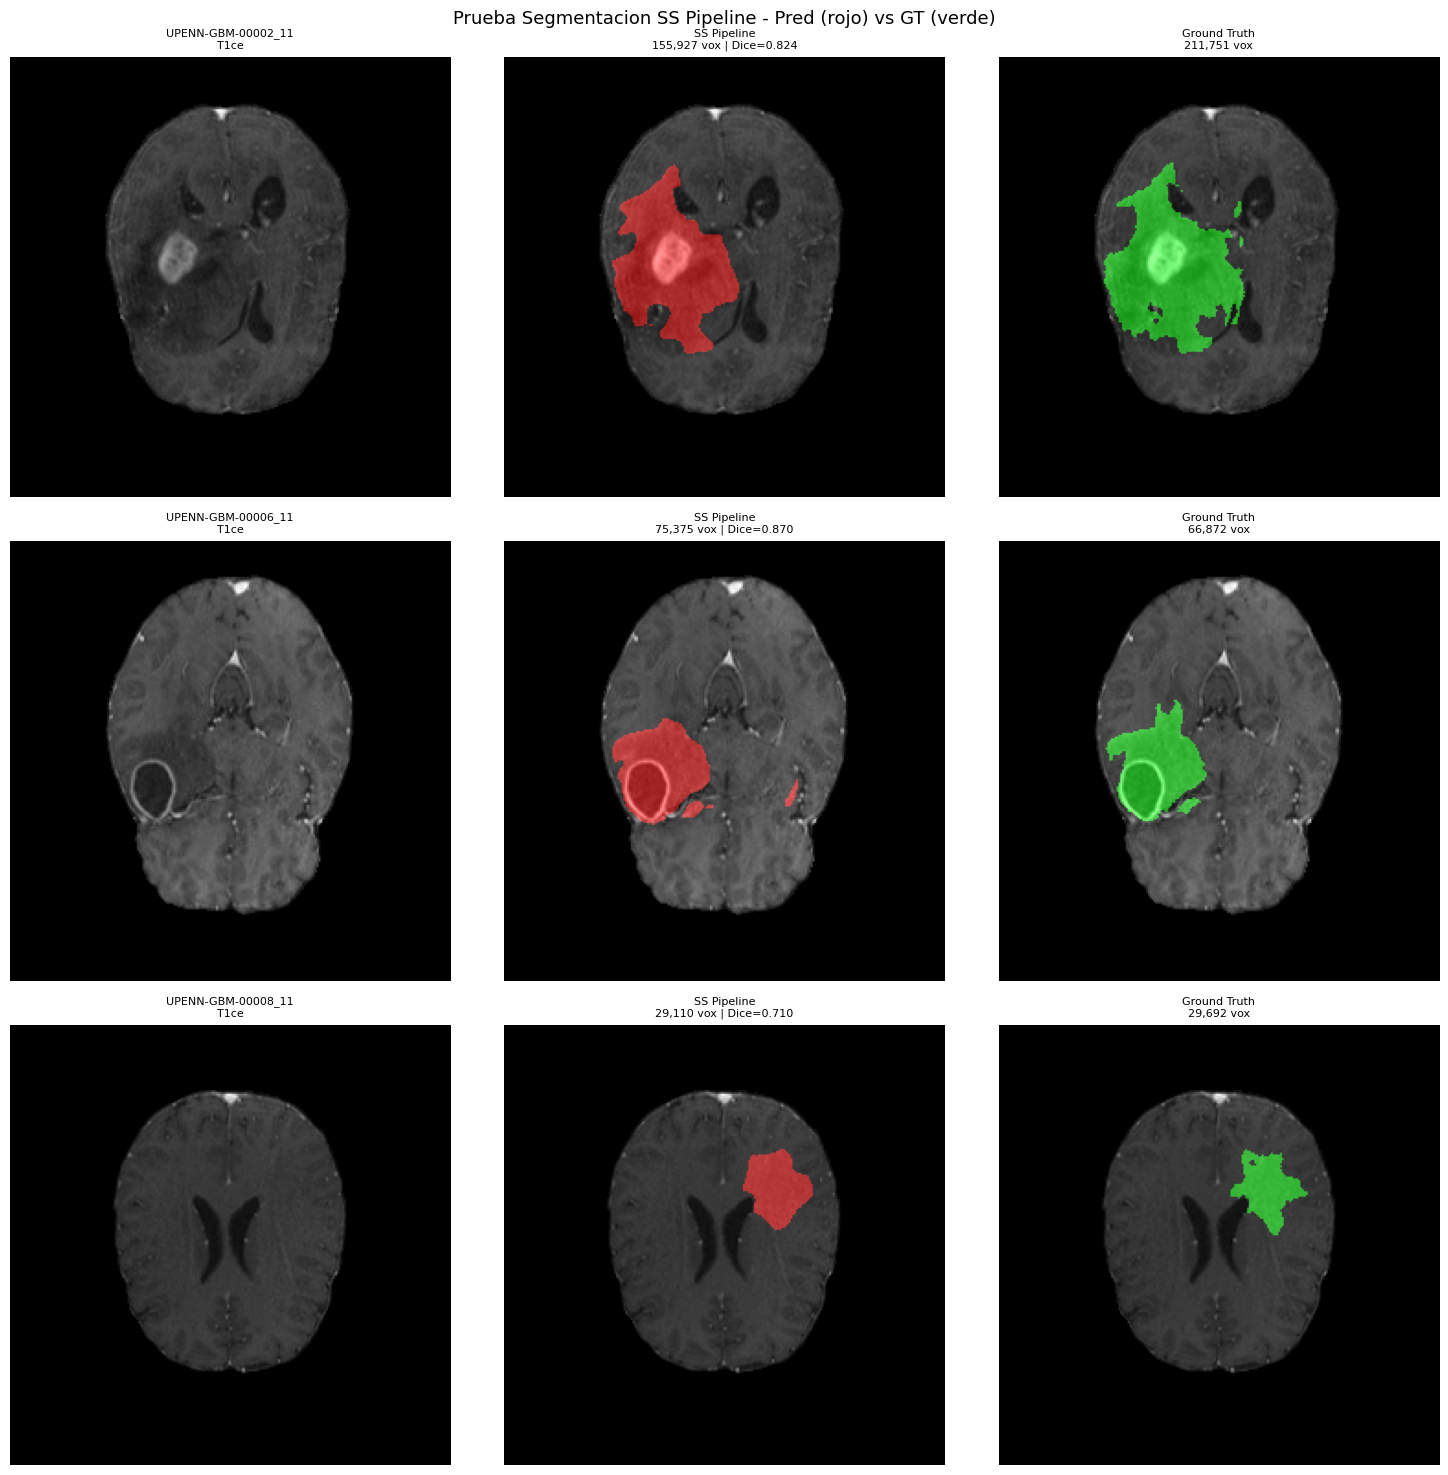


Si los resultados son buenos, procede a correr la celda 9 completa.


In [ ]:
# CELDA 8c - PRUEBA CON 10 CASOS: SEGMENTACION + METRICAS + VISUALIZACION

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import zoom

BASE_DRIVE   = Path('/content/drive/MyDrive/GBM_TESIS')
GT_DIR       = BASE_DRIVE / 'Dataset/images_segm_binary'  # mascaras originales UPENN

def compute_dice(pred: np.ndarray, gt: np.ndarray) -> float:
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin   = (gt   > 0).astype(np.uint8)
    if pred_bin.shape != gt_bin.shape:
        factors  = tuple(p / g for p, g in zip(pred_bin.shape, gt_bin.shape))
        gt_bin   = zoom(gt_bin, factors, order=0)
    intersection = np.sum(pred_bin * gt_bin)
    denom        = np.sum(pred_bin) + np.sum(gt_bin)
    return float(2.0 * intersection / denom) if denom > 0 else 1.0

# Seleccionar 10 casos UPENN que tengan GT disponible
casos_con_gt = []
for _, row in df_cases_drive.iterrows():
    sid     = row['sid']
    gt_path = GT_DIR / f'{sid}_segm.nii.gz'
    if gt_path.exists() and len(casos_con_gt) < 10:
        casos_con_gt.append(row.to_dict())

print(f'Casos con GT disponible para prueba: {len(casos_con_gt)}')

prueba_results = []
for case in tqdm(casos_con_gt, desc='Prueba segmentacion'):
    sid        = case['sid']
    # Usar rutas locales para procesamiento
    case_local = case.copy()
    for col in ['t1', 't1ce', 't2', 'flair']:
        case_local[col] = case[col].replace(str(SS_STRIPPED), str(LOCAL_STRIPPED))
    try:
        result  = run_segmentation_case(case_local, SS_PRED)
        gt_path = GT_DIR / f'{sid}_segm.nii.gz'
        pred    = nib.load(result['seg_path']).get_fdata()
        gt      = nib.load(str(gt_path)).get_fdata()
        dice    = compute_dice(pred, gt)
        prueba_results.append({
            'sid':      sid,
            'status':   'OK',
            'n_voxels': result['n_voxels'],
            'dice':     dice,
            'seg_path': result['seg_path'],
            't1ce':     case['t1ce'],
        })
        print(f'  OK: {sid} | voxeles: {result["n_voxels"]:,} | Dice: {dice:.4f}')
    except Exception as e:
        print(f'  ERROR: {sid} - {e}')
        prueba_results.append({'sid': sid, 'status': 'ERROR', 'dice': None})

# Metricas
dices = [r['dice'] for r in prueba_results if r['dice'] is not None]
print(f'\nDice medio  : {np.mean(dices):.4f}')
print(f'Dice mediana: {np.median(dices):.4f}')
print(f'Dice min    : {np.min(dices):.4f}')
print(f'Dice max    : {np.max(dices):.4f}')

# Visualizacion de 3 casos
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
casos_viz = [r for r in prueba_results if r['status'] == 'OK'][:3]

for i, row in enumerate(casos_viz):
    sid       = row['sid']
    t1ce_data = nib.load(row['t1ce']).get_fdata()
    pred_data = (nib.load(row['seg_path']).get_fdata() > 0).astype(np.uint8)
    gt_data   = (nib.load(str(GT_DIR / f'{sid}_segm.nii.gz')).get_fdata() > 0).astype(np.uint8)

    best_slice = int(np.argmax(pred_data.sum(axis=(0, 1))))
    t1ce_sl    = t1ce_data[:, :, best_slice]
    t1ce_norm  = (t1ce_sl - t1ce_sl.min()) / (t1ce_sl.max() - t1ce_sl.min() + 1e-8)
    pred_sl    = pred_data[:, :, best_slice]
    gt_sl      = gt_data[:, :, best_slice]

    # Imagen original
    axes[i][0].imshow(t1ce_norm.T, cmap='gray', origin='lower')
    axes[i][0].set_title(f'{sid}\nT1ce', fontsize=8)
    axes[i][0].axis('off')

    # Prediccion SS pipeline
    overlay_pred = np.stack([t1ce_norm] * 3, axis=-1)
    overlay_pred[:, :, 0] = np.clip(overlay_pred[:, :, 0] + pred_sl * 0.5, 0, 1)
    axes[i][1].imshow(overlay_pred.transpose(1, 0, 2), origin='lower')
    axes[i][1].set_title(f'SS Pipeline\n{row["n_voxels"]:,} vox | Dice={row["dice"]:.3f}', fontsize=8)
    axes[i][1].axis('off')

    # Ground truth
    overlay_gt = np.stack([t1ce_norm] * 3, axis=-1)
    overlay_gt[:, :, 1] = np.clip(overlay_gt[:, :, 1] + gt_sl * 0.5, 0, 1)
    axes[i][2].imshow(overlay_gt.transpose(1, 0, 2), origin='lower')
    axes[i][2].set_title(f'Ground Truth\n{int(gt_data.sum()):,} vox', fontsize=8)
    axes[i][2].axis('off')

plt.suptitle('Prueba Segmentacion SS Pipeline - Pred (rojo) vs GT (verde)', fontsize=13)
plt.tight_layout()
plt.savefig(SS_FIGURES / 'segmentation_prueba_10casos.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSi los resultados son buenos, procede a correr la celda 9 completa.')

In [ ]:
# CELDA 9 - Pipeline completo de segmentacion
# TIEMPO ESTIMADO con A100 + datos locales: ~8-12 horas
# Se puede interrumpir y reanudar

seg_log_path = SS_METRICS / 'segmentation_log.csv'
seg_results  = []

processed_sids = set()
if seg_log_path.exists():
    df_prev = pd.read_csv(str(seg_log_path))
    processed_sids = set(df_prev[df_prev['status'] == 'OK']['sid'].tolist())
    seg_results = df_prev.to_dict('records')
    print(f'Casos ya segmentados: {len(processed_sids)}')

pending = df_cases[~df_cases['sid'].isin(processed_sids)].to_dict('records')
print(f'Casos pendientes: {len(pending)} de {len(df_cases)}')

for case in tqdm(pending, desc='Segmentacion BraTS23'):
    sid = case['sid']
    try:
        result = run_segmentation_case(case, SS_PRED)
        seg_results.append({
            'sid':      sid,
            'source':   case['source'],
            'status':   'OK',
            'seg_path': result['seg_path'],
            'n_voxels': result['n_voxels'],
            'error':    '',
        })
    except Exception as e:
        print(f'  ERROR {sid}: {e}')
        traceback.print_exc()
        seg_results.append({
            'sid':      sid,
            'source':   case['source'],
            'status':   'ERROR',
            'seg_path': '',
            'n_voxels': 0,
            'error':    str(e),
        })

    if len(seg_results) % 10 == 0:
        pd.DataFrame(seg_results).to_csv(str(seg_log_path), index=False)

df_seg = pd.DataFrame(seg_results)
df_seg.to_csv(str(seg_log_path), index=False)

print(f'\nSegmentados OK : {(df_seg["status"] == "OK").sum()}')
print(f'Errores        : {(df_seg["status"] == "ERROR").sum()}')

Casos pendientes: 722 de 722


Segmentacion BraTS23: 100%|██████████| 722/722 [20:26<00:00,  1.70s/it]


Segmentados OK : 722
Errores        : 0


In [ ]:
# CELDA 9b - Recargar desde Drive si hubo reinicio
# Tambien re-copia datos locales si se perdieron

seg_log_path = SS_METRICS / 'segmentation_log.csv'
df_seg       = pd.read_csv(str(seg_log_path))
print(f'Casos cargados : {len(df_seg)}')
print(f'OK             : {(df_seg["status"] == "OK").sum()}')
print(f'ERROR          : {(df_seg["status"] == "ERROR").sum()}')

if not LOCAL_STRIPPED.exists():
    print('\nDatos locales perdidos. Recopiando desde Drive...')
    shutil.copytree(str(SS_STRIPPED), str(LOCAL_STRIPPED))
    print('Recopiado exitosamente.')
else:
    print(f'Datos locales OK: {len(list(LOCAL_STRIPPED.iterdir()))} casos')

Casos cargados : 722
OK             : 722
ERROR          : 0
Datos locales OK: 722 casos


In [ ]:
# CELDA 10 - Estadisticas de segmentacion

df_seg_ok = df_seg[df_seg['status'] == 'OK'].copy()

print('=' * 60)
print('RESUMEN SEGMENTACION - SegResNet BraTS23')
print('SS Pipeline - Notebook SS_02')
print('=' * 60)
print(f'Total casos         : {len(df_seg)}')
print(f'Segmentados OK      : {len(df_seg_ok)}')
print(f'Errores             : {len(df_seg) - len(df_seg_ok)}')
print(f'\nVoxeles tumorales:')
print(f'  Media   : {df_seg_ok["n_voxels"].mean():.0f}')
print(f'  Mediana : {df_seg_ok["n_voxels"].median():.0f}')
print(f'  Min     : {df_seg_ok["n_voxels"].min()}')
print(f'  Max     : {df_seg_ok["n_voxels"].max()}')
print(f'\nCasos sin tumor (< 50 voxeles): {(df_seg_ok["n_voxels"] < 50).sum()}')

summary_path = SS_METRICS / 'segmentation_summary.txt'
with open(summary_path, 'w') as f:
    f.write('=' * 60 + '\n')
    f.write('RESUMEN SEGMENTACION - SegResNet BraTS23\n')
    f.write('SS Pipeline - Notebook SS_02\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Total casos         : {len(df_seg)}\n')
    f.write(f'Segmentados OK      : {len(df_seg_ok)}\n')
    f.write(f'Errores             : {len(df_seg) - len(df_seg_ok)}\n')
    f.write(f'\nVoxeles tumorales:\n')
    f.write(f'  Media   : {df_seg_ok["n_voxels"].mean():.0f}\n')
    f.write(f'  Mediana : {df_seg_ok["n_voxels"].median():.0f}\n')
    f.write(f'  Min     : {df_seg_ok["n_voxels"].min()}\n')
    f.write(f'  Max     : {df_seg_ok["n_voxels"].max()}\n')
print(f'Resumen guardado en: {summary_path}')

RESUMEN SEGMENTACION - SegResNet BraTS23
SS Pipeline - Notebook SS_02
Total casos         : 722
Segmentados OK      : 722
Errores             : 0

Voxeles tumorales:
  Media   : 72346
  Mediana : 67558
  Min     : 168
  Max     : 200092

Casos sin tumor (< 50 voxeles): 0
Resumen guardado en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/metrics/segmentation_summary.txt


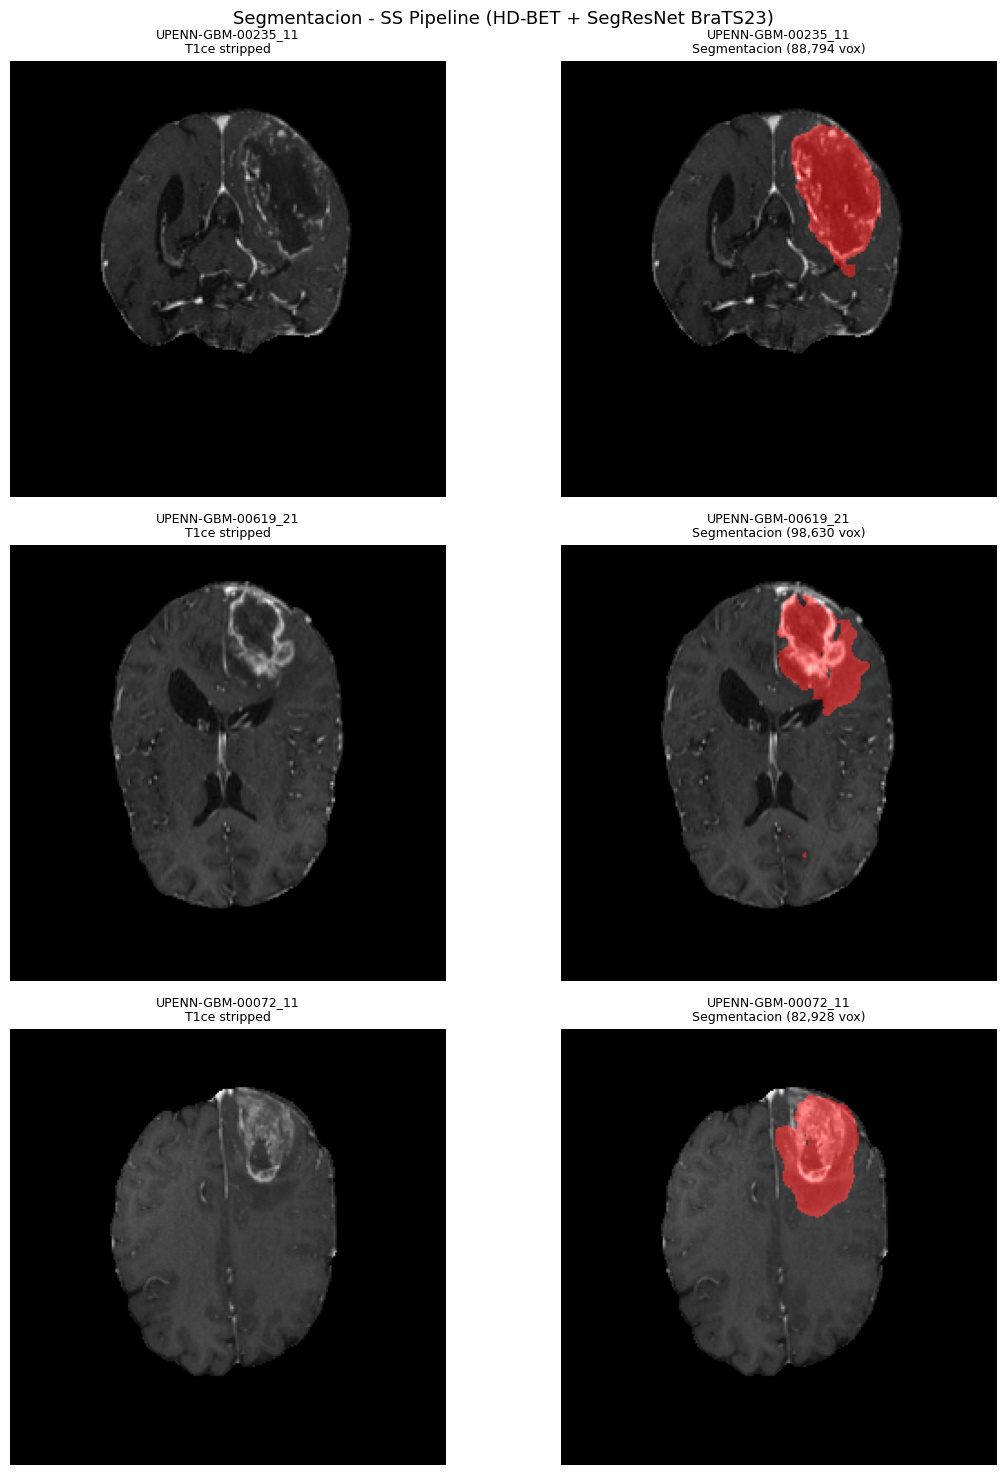

Figura guardada.


In [ ]:
# CELDA 11 - Visualizacion de segmentaciones

df_viz = df_seg_ok[df_seg_ok['n_voxels'] > 1000].sample(3, random_state=42)

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for i, (_, row) in enumerate(df_viz.iterrows()):
    sid       = row['sid']
    t1ce_row  = df_cases_drive[df_cases_drive['sid'] == sid].iloc[0]
    t1ce_data = nib.load(t1ce_row['t1ce']).get_fdata()
    seg_data  = (nib.load(row['seg_path']).get_fdata() > 0).astype(np.uint8)

    best_slice = int(np.argmax(seg_data.sum(axis=(0, 1))))
    t1ce_sl    = t1ce_data[:, :, best_slice]
    t1ce_norm  = (t1ce_sl - t1ce_sl.min()) / (t1ce_sl.max() - t1ce_sl.min() + 1e-8)
    seg_sl     = seg_data[:, :, best_slice]

    overlay = np.stack([t1ce_norm] * 3, axis=-1)
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] + seg_sl * 0.5, 0, 1)

    axes[i][0].imshow(t1ce_norm.T, cmap='gray', origin='lower')
    axes[i][0].set_title(f'{sid}\nT1ce stripped', fontsize=9)
    axes[i][0].axis('off')

    axes[i][1].imshow(overlay.transpose(1, 0, 2), origin='lower')
    axes[i][1].set_title(f'{sid}\nSegmentacion ({row["n_voxels"]:,} vox)', fontsize=9)
    axes[i][1].axis('off')

plt.suptitle('Segmentacion - SS Pipeline (HD-BET + SegResNet BraTS23)', fontsize=13)
plt.tight_layout()
plt.savefig(SS_FIGURES / 'segmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

In [ ]:
# CELDA 12 - Guardar indice para SS_03
# Usa rutas Drive (no locales) para garantizar persistencia

df_merged = df_cases_drive.merge(
    df_seg_ok[['sid', 'seg_path', 'n_voxels']],
    on='sid',
    how='inner',
)

seg_index_path = SS_DIR / 'ss_seg_index.csv'
df_merged.to_csv(str(seg_index_path), index=False)

print(f'Indice guardado en    : {seg_index_path}')
print(f'Total casos para SS_03: {len(df_merged)}')
print(f'Columnas              : {df_merged.columns.tolist()}')
print(f'\nPrimeros 3 casos:')
print(df_merged[['sid', 'source', 'n_voxels']].head(3).to_string(index=False))

Indice guardado en    : /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/ss_seg_index.csv
Total casos para SS_03: 722
Columnas              : ['sid', 'source', 'status', 'brain_voxels', 't1', 't1ce', 't2', 'flair', 'error', 'seg_path', 'n_voxels']

Primeros 3 casos:
               sid           source  n_voxels
UPENN-GBM-00001_11 UPENN_unstripped     31349
UPENN-GBM-00002_11 UPENN_unstripped    155927
UPENN-GBM-00003_11 UPENN_unstripped     68774


Calculando metricas...


100%|██████████| 722/722 [01:00<00:00, 11.87it/s]



Casos evaluados con GT: 147
METRICAS SEGMENTACION SS PIPELINE - SegResNet BraTS23

DICE:
  Media   : 0.8364
  Mediana : 0.8698
  Std     : 0.1018
  Min     : 0.2474
  Max     : 0.9610

PRECISION:
  Media   : 0.8855
  Mediana : 0.9042
  Std     : 0.0838
  Min     : 0.5740
  Max     : 0.9932

RECALL:
  Media   : 0.8109
  Mediana : 0.8475
  Std     : 0.1484
  Min     : 0.1554
  Max     : 0.9904

IOU:
  Media   : 0.7301
  Mediana : 0.7696
  Std     : 0.1310
  Min     : 0.1412
  Max     : 0.9249

Casos Dice >= 0.80: 108 / 147
Casos Dice >= 0.70: 133 / 147
Casos Dice < 0.50 : 2 / 147

COMPARACION SS vs PIPELINE ORIGINAL
Metrica          SS Pipeline     Original
----------------------------------------
Dice medio            0.8364       0.8000
Dice mediana          0.8698       0.8600


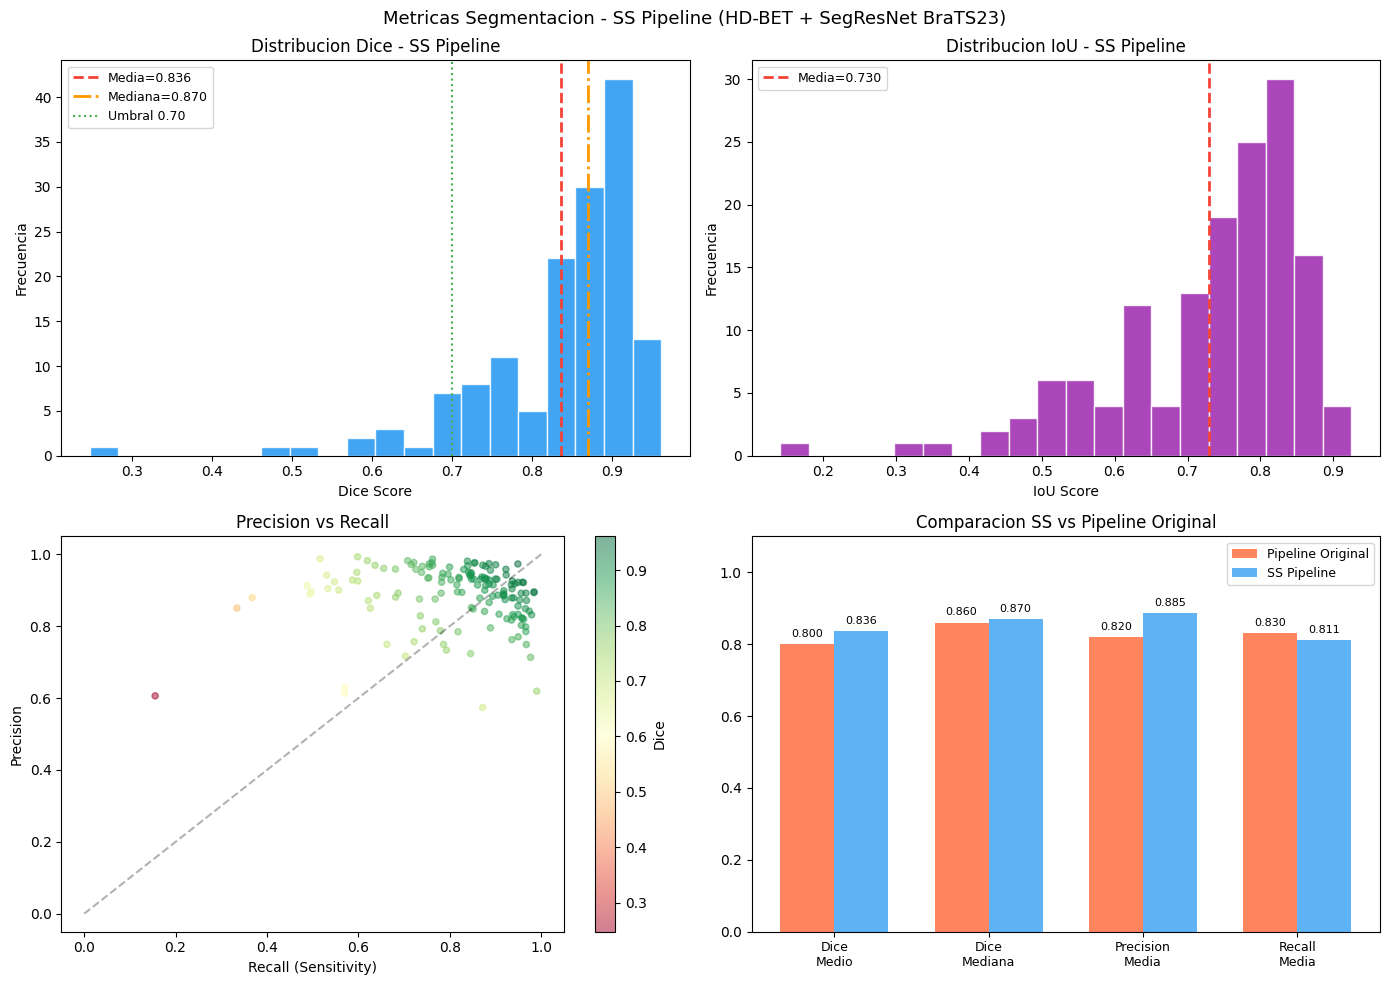

Metricas guardadas.


In [ ]:
# CELDA 13 - Métricas de segmentación y comparación con pipeline originalimport nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import zoom
from tqdm import tqdm

BASE_DRIVE = Path('/content/drive/MyDrive/GBM_TESIS')
SS_DIR     = Path('/content/drive/MyDrive/GBM_TESIS/SS_PIPELINE')
GT_DIR     = BASE_DRIVE / 'Dataset/images_segm_binary'
SS_PRED    = SS_DIR / 'predictions'
SS_METRICS = SS_DIR / 'metrics'
SS_FIGURES = SS_DIR / 'figures'

df_seg = pd.read_csv(str(SS_METRICS / 'segmentation_log.csv'))
df_ok  = df_seg[df_seg['status'] == 'OK'].copy()

def compute_metrics(pred: np.ndarray, gt: np.ndarray):
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin   = (gt   > 0).astype(np.uint8)
    if pred_bin.shape != gt_bin.shape:
        factors  = tuple(p / g for p, g in zip(pred_bin.shape, gt_bin.shape))
        gt_bin   = zoom(gt_bin, factors, order=0)
    tp = np.sum(pred_bin * gt_bin)
    fp = np.sum(pred_bin * (1 - gt_bin))
    fn = np.sum((1 - pred_bin) * gt_bin)
    tn = np.sum((1 - pred_bin) * (1 - gt_bin))
    dice      = 2*tp / (2*tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)
    return {'dice': float(dice), 'precision': float(precision),
            'recall': float(recall), 'iou': float(iou)}

# Calcular metricas para casos con GT disponible
print('Calculando metricas...')
metrics_list = []
for _, row in tqdm(df_ok.iterrows(), total=len(df_ok)):
    sid     = row['sid']
    gt_path = GT_DIR / f'{sid}_segm.nii.gz'
    if not gt_path.exists():
        continue
    pred = nib.load(row['seg_path']).get_fdata()
    gt   = nib.load(str(gt_path)).get_fdata()
    m    = compute_metrics(pred, gt)
    m['sid']      = sid
    m['n_voxels'] = row['n_voxels']
    metrics_list.append(m)

df_metrics = pd.DataFrame(metrics_list)
df_metrics.to_csv(str(SS_METRICS / 'segmentation_metrics.csv'), index=False)

print(f'\nCasos evaluados con GT: {len(df_metrics)}')
print('=' * 55)
print('METRICAS SEGMENTACION SS PIPELINE - SegResNet BraTS23')
print('=' * 55)
for metric in ['dice', 'precision', 'recall', 'iou']:
    vals = df_metrics[metric]
    print(f'\n{metric.upper()}:')
    print(f'  Media   : {vals.mean():.4f}')
    print(f'  Mediana : {vals.median():.4f}')
    print(f'  Std     : {vals.std():.4f}')
    print(f'  Min     : {vals.min():.4f}')
    print(f'  Max     : {vals.max():.4f}')

print(f'\nCasos Dice >= 0.80: {(df_metrics["dice"] >= 0.80).sum()} / {len(df_metrics)}')
print(f'Casos Dice >= 0.70: {(df_metrics["dice"] >= 0.70).sum()} / {len(df_metrics)}')
print(f'Casos Dice < 0.50 : {(df_metrics["dice"] < 0.50).sum()} / {len(df_metrics)}')

# Comparacion con pipeline original
print('\n' + '=' * 55)
print('COMPARACION SS vs PIPELINE ORIGINAL')
print('=' * 55)
print(f'{"Metrica":<15} {"SS Pipeline":>12} {"Original":>12}')
print('-' * 40)
print(f'{"Dice medio":<15} {df_metrics["dice"].mean():>12.4f} {"0.8000":>12}')
print(f'{"Dice mediana":<15} {df_metrics["dice"].median():>12.4f} {"0.8600":>12}')

# Figuras
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma Dice
axes[0][0].hist(df_metrics['dice'], bins=20, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0][0].axvline(df_metrics['dice'].mean(),   color='#F44336', lw=2, ls='--', label=f'Media={df_metrics["dice"].mean():.3f}')
axes[0][0].axvline(df_metrics['dice'].median(), color='#FF9800', lw=2, ls='-.', label=f'Mediana={df_metrics["dice"].median():.3f}')
axes[0][0].axvline(0.70, color='#4CAF50', lw=1.5, ls=':', label='Umbral 0.70')
axes[0][0].set_xlabel('Dice Score')
axes[0][0].set_ylabel('Frecuencia')
axes[0][0].set_title('Distribucion Dice - SS Pipeline')
axes[0][0].legend(fontsize=9)

# Histograma IoU
axes[0][1].hist(df_metrics['iou'], bins=20, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[0][1].axvline(df_metrics['iou'].mean(), color='#F44336', lw=2, ls='--', label=f'Media={df_metrics["iou"].mean():.3f}')
axes[0][1].set_xlabel('IoU Score')
axes[0][1].set_ylabel('Frecuencia')
axes[0][1].set_title('Distribucion IoU - SS Pipeline')
axes[0][1].legend(fontsize=9)

# Precision vs Recall
axes[1][0].scatter(df_metrics['recall'], df_metrics['precision'],
                   alpha=0.5, c=df_metrics['dice'], cmap='RdYlGn', s=20)
axes[1][0].set_xlabel('Recall (Sensitivity)')
axes[1][0].set_ylabel('Precision')
axes[1][0].set_title('Precision vs Recall')
axes[1][0].plot([0,1],[0,1], 'k--', alpha=0.3)
im = axes[1][0].scatter([], [], c=[], cmap='RdYlGn')
plt.colorbar(axes[1][0].collections[0], ax=axes[1][0], label='Dice')

# Comparacion SS vs Original
metrics_comp = ['Dice\nMedio', 'Dice\nMediana', 'Precision\nMedia', 'Recall\nMedia']
ss_vals      = [df_metrics['dice'].mean(), df_metrics['dice'].median(),
                df_metrics['precision'].mean(), df_metrics['recall'].mean()]
orig_vals    = [0.80, 0.86, 0.82, 0.83]  # valores aproximados pipeline original
x = np.arange(len(metrics_comp))
w = 0.35
axes[1][1].bar(x - w/2, orig_vals, w, label='Pipeline Original', color='#FF7043', alpha=0.85)
axes[1][1].bar(x + w/2, ss_vals,   w, label='SS Pipeline',       color='#42A5F5', alpha=0.85)
axes[1][1].set_xticks(x)
axes[1][1].set_xticklabels(metrics_comp, fontsize=9)
axes[1][1].set_ylim(0, 1.1)
axes[1][1].set_title('Comparacion SS vs Pipeline Original')
axes[1][1].legend(fontsize=9)
for i, (o, s) in enumerate(zip(orig_vals, ss_vals)):
    axes[1][1].text(i - w/2, o + 0.02, f'{o:.3f}', ha='center', fontsize=8)
    axes[1][1].text(i + w/2, s + 0.02, f'{s:.3f}', ha='center', fontsize=8)

plt.suptitle('Metricas Segmentacion - SS Pipeline (HD-BET + SegResNet BraTS23)', fontsize=13)
plt.tight_layout()
plt.savefig(SS_FIGURES / 'segmentation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metricas guardadas.')